# Stacking Regressor + Ridge CV

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# 1. Baca data (gunakan header=None karena .data tidak punya nama kolom)
# Gunakan na_values='?' karena data yang hilang ditandai dengan tanda tanya
df_final= pd.read_csv('communities.data', header=None, na_values='?')

df_final.columns = [f"feat_{i}" for i in range(df_final.shape[1])]

# 2. SEPARASI FITUR DAN TARGET
# X hanya mengambil 10 kolom fitur dari RFE secara eksplisit
X = df_final[['feat_49', 'feat_55', 'feat_48', 'feat_54', 'feat_8', 'feat_33', 'feat_73', 'feat_43', 'feat_74', 'feat_29']]
y = df_final['feat_127']

In [3]:
# # 2. FEATURE ENGINEERING (Interaksi Antar Fitur)
# # Menambahkan fitur interaksi untuk menangkap hubungan non-linier yang kompleks
# poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
# X_poly = poly.fit_transform(X)
# X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(X.columns))

In [4]:
from sklearn.impute import SimpleImputer
# 3. SPLIT & SCALING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 4. IMPUTASI (Mengisi nilai NaN dengan Median agar tidak eror)
# Proses ini dilakukan setelah split untuk menghindari Data Leakage
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 5. SCALING (Menggunakan data yang sudah di-imputasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import (
    StackingRegressor, RandomForestRegressor, 
    ExtraTreesRegressor, GradientBoostingRegressor, 
    AdaBoostRegressor
)
from sklearn.linear_model import RidgeCV, Lasso, LinearRegression
from sklearn.svm import SVR
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags

# 4. DEFINISI MODEL UNTUK STACKING (Wrapped for Compatibility)
estimators = [
    ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
]

In [6]:
# Using RidgeCV as the final meta-learner to weigh all these models
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=5,
    passthrough=True  # Meta-learner sees original features + predictions
)

print("🚀 Training Full Stacking Ensemble (9 Models)...")
try:
    stacking_model.fit(X_train_scaled, y_train)
    print("✅ Stacking Ensemble trained successfully!")
except Exception as e:
    print(f"⚠️ Training error: {e}")
    print("Attempting alternative approach with unwrapped models...")
    # If stacking fails, we can try with individual models

🚀 Training Full Stacking Ensemble (9 Models)...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✅ Stacking Ensemble trained successfully!


In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, max_error
import numpy as np

# 6. PREDIKSI DAN EVALUASI
y_pred = stacking_model.predict(X_test_scaled)

# Existing metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# New metrics
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
max_err = max_error(y_test, y_pred)
min_err = np.min(np.abs(y_test - y_pred)) # Absolute minimum error

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [8]:
print("\n" + "="*30)
print("HASIL EVALUASI MODEL")
print("="*30)
print(f"R-Squared (R2)  : {r2:.4f}")
print(f"Mean Abs Error  : {mae:.4f}")
print(f"Root MSE (RMSE) : {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Max Error: {max_err:.4f}")
print(f"Min Error: {min_err:.4f}")


HASIL EVALUASI MODEL
R-Squared (R2)  : 0.6249
Mean Abs Error  : 0.0863
Root MSE (RMSE) : 0.1309
MAPE: inf%
Max Error: 0.6074
Min Error: 0.0001



==============================
HASIL EVALUASI MODEL TANPA FEATURE ENGINEERING
==============================
R-Squared (R2)  : 0.6385
Mean Abs Error  : 0.0878
Root MSE (RMSE) : 0.1285
MAPE: inf%
Max Error: 0.5561
Min Error: 0.0002

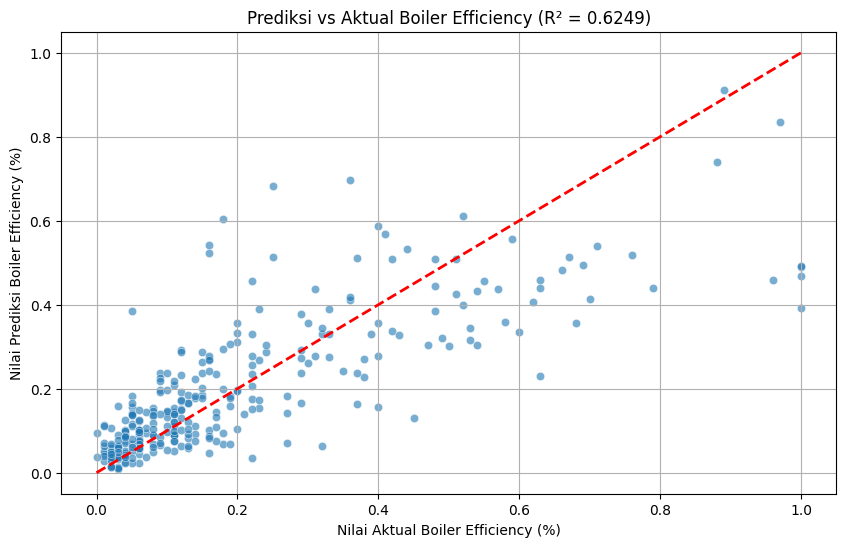

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. VISUALISASI HASIL PREDIKSI VS AKTUAL
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Nilai Aktual Boiler Efficiency (%)')
plt.ylabel('Nilai Prediksi Boiler Efficiency (%)')
plt.title(f'Prediksi vs Aktual Boiler Efficiency (R² = {r2:.4f})')
plt.grid(True)
plt.show()

In [10]:
import pandas as pd

# 7. TABEL PERBANDINGAN AKTUAL VS PREDIKSI
# Membuat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Absolute Error': np.abs(y_test - y_pred),
    'Percentage Error (%)': np.abs((y_test - y_pred) / y_test) * 100
})

# Menampilkan 10 baris pertama untuk pengecekan
print("Comparison Table (First 10 rows):")
print(comparison_df.head(10))

# Opsional: Simpan ke CSV jika diperlukan untuk laporan SEO
# comparison_df.to_csv('model_predictions_comparison.csv', index=False)

Comparison Table (First 10 rows):
      Actual Value  Predicted Value  Absolute Error  Percentage Error (%)
889           0.22         0.175440        0.044560             20.254378
1672          0.04         0.043503        0.003503              8.758498
414           0.10         0.145408        0.045408             45.407730
1599          0.08         0.089418        0.009418             11.773064
849           0.04         0.046398        0.006398             15.994799
1658          0.05         0.115637        0.065637            131.273461
926           0.23         0.267565        0.037565             16.332656
1670          0.48         0.509325        0.029325              6.109434
1448          0.04         0.039168        0.000832              2.080061
1216          0.20         0.311904        0.111904             55.951790


In [11]:
# 8. EXPORT TO EXCEL
# Menentukan nama file
file_name = "d. prediction results M4 dataset C&C UCI ML.xlsx"

# Menyimpan DataFrame ke file Excel
comparison_df.to_excel(file_name, index=False)

print(f"Data successfully saved to {file_name}!")

Data successfully saved to d. prediction results M4 dataset C&C UCI ML.xlsx!
